In [32]:
import pandas as pd
import numpy as np
import healpy as hp

def calculate_ghi_from_skymap(skymap_file, metadata_file):
    """
    Calculate the total global horizontal irradiation (GHI) from a skymap.
    For a horizontal surface, we simply integrate the sky radiance weighted by 
    cos(zenith) over the entire hemisphere.
    """
    # Load data
    skymap_df = pd.read_csv(skymap_file)
    metadata_df = pd.read_csv(metadata_file)
    metadata = metadata_df.iloc[0].to_dict()
    
    # Extract key info
    nside = int(metadata['nside'])
    daylight_timesteps = int(metadata['daylight_timesteps_processed'])
    total_ghi_from_metadata = metadata['total_ghi_period']
    avg_ghi_from_metadata = metadata['average_ghi_daylight']
    
    # Calculate zenith angle for each HEALPix pixel
    # For HEALPix, theta is colatitude (zenith) and elevation = pi/2 - theta
    elevation_rad = np.radians(skymap_df['elevation_deg'])
    zenith_rad = np.pi/2 - elevation_rad
    
    # Integration weight is cos(zenith) * pixel_solid_angle
    pixel_solid_angle = hp.nside2pixarea(nside)
    weights = np.cos(zenith_rad) * pixel_solid_angle
    
    # Only integrate pixels above horizon (elevation > 0)
    above_horizon = elevation_rad > 1e-6
    visible_pixels = skymap_df[above_horizon]
    visible_weights = weights[above_horizon]
    
    # Calculate GHI: Sum(L_sky * cos(zenith) * pixel_solid_angle)
    ghi_per_hour = np.sum(visible_pixels['average_radiance_W_m2_sr'] * visible_weights)
    
    # Annual GHI (energy) = GHI per hour * daylight hours
    annual_ghi_energy = ghi_per_hour * daylight_timesteps  # Wh/m²
    annual_ghi_energy_kwh = annual_ghi_energy / 1000  # kWh/m²
    
    # Compare with metadata values
    total_ghi_metadata_kwh = total_ghi_from_metadata / 1000
    calculated_avg_ghi = ghi_per_hour
    
    print(f"### Sanity Check Results ###")
    print(f"From skymap integration:")
    print(f"  - GHI per daylight hour: {ghi_per_hour:.2f} W/m²")
    print(f"  - Annual GHI energy: {annual_ghi_energy_kwh:.2f} kWh/m²")
    print(f"\nFrom metadata:")
    print(f"  - Average GHI per daylight hour: {avg_ghi_from_metadata:.2f} W/m²")
    print(f"  - Total GHI for period: {total_ghi_metadata_kwh:.2f} kWh/m²")
    print(f"\nDifferences:")
    print(f"  - GHI per hour difference: {(ghi_per_hour - avg_ghi_from_metadata):.2f} W/m²")
    print(f"  - Annual energy difference: {(annual_ghi_energy_kwh - total_ghi_metadata_kwh):.2f} kWh/m²")
    print(f"  - Relative error: {((annual_ghi_energy_kwh - total_ghi_metadata_kwh) / total_ghi_metadata_kwh * 100):.2f}%")
    
    return ghi_per_hour, annual_ghi_energy_kwh, total_ghi_metadata_kwh

# Example usage:
if __name__ == "__main__":
    skymap_file = "aggregated_results_claude_poa_comparison/676147_2018_yearly_skymap.csv"
    metadata_file = "aggregated_results_claude_poa_comparison/676147_2018_yearly_metadata.csv"
    
    calculate_ghi_from_skymap(skymap_file, metadata_file)

### Sanity Check Results ###
From skymap integration:
  - GHI per daylight hour: 265.95 W/m²
  - Annual GHI energy: 1181.63 kWh/m²

From metadata:
  - Average GHI per daylight hour: 271.24 W/m²
  - Total GHI for period: 1205.12 kWh/m²

Differences:
  - GHI per hour difference: -5.29 W/m²
  - Annual energy difference: -23.49 kWh/m²
  - Relative error: -1.95%


In [34]:
import pandas as pd
import numpy as np
import healpy as hp
import os
from typing import List, Dict, Tuple, Optional # <-- Added Tuple here
from dataclasses import dataclass, field
from pvlib.solarposition import get_solarposition # Added this import as it's used

def calculate_cos_aoi(surface_tilt_deg: float, surface_azimuth_deg: float, nside: int) -> np.ndarray:
    """
    Calculates the cosine of the angle of incidence (cos(AOI)) for every
    HEALPix pixel relative to a tilted surface.

    Args:
        surface_tilt_deg (float): Tilt angle of the surface from horizontal (0=horizontal, 90=vertical).
        surface_azimuth_deg (float): Azimuth angle of the surface normal
                                     (0=North, 90=East, 180=South, 270=West).
        nside (int): HEALPix resolution parameter.

    Returns:
        np.ndarray: Array containing cos(AOI) for each HEALPix pixel.
                    Values are clipped to be >= 0 (surface only sees pixels in front).
    """
    npix = hp.nside2npix(nside)
    pixels = np.arange(npix)

    # Get pixel center coordinates (theta: zenith angle, phi: math azimuth E=0)
    theta_pix_rad, phi_pix_rad = hp.pix2ang(nside, pixels)

    # Convert surface parameters to radians and correct conventions
    surface_tilt_rad = np.radians(surface_tilt_deg)
    # Convert surface azimuth (Nav) to math azimuth (E=0) for the formula
    surface_azimuth_rad_nav = np.radians(surface_azimuth_deg)
    surface_azimuth_rad_math = (np.pi / 2 - surface_azimuth_rad_nav) % (2 * np.pi)

    # Formula for cos(Angle of Incidence) between surface normal and vector TO the pixel center:
    # cos(AOI) = cos(tilt) * cos(zenith_pix) +
    #            sin(tilt) * sin(zenith_pix) * cos(azimuth_pix - surface_azimuth_math)
    cos_aoi = (np.cos(surface_tilt_rad) * np.cos(theta_pix_rad) +
               np.sin(surface_tilt_rad) * np.sin(theta_pix_rad) *
               np.cos(phi_pix_rad - surface_azimuth_rad_math))

    # Clip negative values (pixels behind the surface or below horizon relative to surface)
    cos_aoi_clipped = np.maximum(0, cos_aoi)

    return cos_aoi_clipped

def calculate_tilted_surface_irradiation(
    skymap_csv_path: str,
    surface_tilt_deg: float,
    surface_azimuth_deg: float,
    hours_in_period: float
) -> Tuple[float, float]:
    """
    Calculates the average irradiance and total irradiation on a tilted surface
    using an aggregated average radiance skymap CSV.

    Args:
        skymap_csv_path (str): Path to the '_skymap.csv' file.
        surface_tilt_deg (float): Tilt angle of the surface (degrees).
        surface_azimuth_deg (float): Azimuth angle of the surface (degrees, N=0).
        hours_in_period (float): Duration represented by the skymap (e.g., 8760 for a year).

    Returns:
        Tuple[float, float]:
            - Average irradiance on the tilted surface (W/m²).
            - Total irradiation (energy) on the tilted surface (kWh/m²).
    """
    if not os.path.exists(skymap_csv_path):
        raise FileNotFoundError(f"Skymap CSV file not found: {skymap_csv_path}")

    # --- 1. Load Data ---
    skymap_df = pd.read_csv(skymap_csv_path)
    if 'average_radiance_W_m2_sr' not in skymap_df.columns:
        raise ValueError("CSV must contain 'average_radiance_W_m2_sr' column.")

    average_radiance_map = skymap_df['average_radiance_W_m2_sr'].values # W/m²/sr
    npix = len(average_radiance_map)
    try:
        nside = hp.npix2nside(npix)
    except ValueError as e:
        raise ValueError(f"Invalid number of pixels ({npix}) for HEALPix grid: {e}")

    # --- 2. Get HEALPix Geometry ---
    pixel_solid_angle = hp.nside2pixarea(nside) # sr

    # --- 3. Calculate Angle of Incidence ---
    cos_aoi_clipped = calculate_cos_aoi(surface_tilt_deg, surface_azimuth_deg, nside)

    # --- 4. Calculate Irradiance Contribution from each pixel ---
    # Irradiance_i = Radiance_i * cos(AOI_i) * Solid_Angle_i   (Units: W/m²)
    irradiance_per_pixel = average_radiance_map * cos_aoi_clipped * pixel_solid_angle

    # --- 5. Calculate Average Total Irradiance on Surface ---
    # Sum contributions from all pixels
    average_total_irradiance_tilted = np.sum(irradiance_per_pixel) # W/m²

    # --- 6. Calculate Total Energy (Irradiation) ---
    # Energy = Average Power * Duration
    total_irradiation_wh = average_total_irradiance_tilted * hours_in_period # Wh/m²
    total_irradiation_kwh = total_irradiation_wh / 1000.0 # kWh/m²

    return average_total_irradiance_tilted, total_irradiation_kwh

# --- Main Execution ---
if __name__ == "__main__":
    # --- Configuration ---
    # Specify the path to your yearly aggregated skymap CSV file
    # Example: Use the first location and year from the previous summary
    # You'll need to know the location_id and year from your previous run.
    #LOCATION_ID = "682979" # <<< --- CHANGE TO YOUR LOCATION ID
    #YEAR = 2017          # <<< --- CHANGE TO YOUR YEAR
    #AGGREGATED_DATA_PATH = "aggregated_results_claude_poa_comparison" # Path where CSVs were saved

    #SKYMAP_FILENAME = f"{LOCATION_ID}_{YEAR}_skymap.csv"
    SKYMAP_FILE_PATH = "aggregated_results_claude_poa_comparison/697868_2018_yearly_skymap.csv"#os.path.join(AGGREGATED_DATA_PATH, SKYMAP_FILENAME)

    # Solar Panel Configuration
    SURFACE_TILT = 30.0   # degrees from horizontal
    SURFACE_AZIMUTH = 180.0 # degrees (180 = South)
    HOURS_IN_YEAR = 24 * 365.25 # Use average to account for leap years slightly

    # --- Calculation ---
    try:
        avg_irradiance, total_kwh = calculate_tilted_surface_irradiation(
            SKYMAP_FILE_PATH,
            SURFACE_TILT,
            SURFACE_AZIMUTH,
            HOURS_IN_YEAR
        )

        # --- Output Results ---
        print("-" * 50)
        print(f"Irradiation Calculation for 1m² Surface")
        print("-" * 50)
        print(f"Location ID:          {LOCATION_ID}")
        print(f"Year:                 {YEAR}")
        print(f"Skymap File:          {SKYMAP_FILENAME}")
        print(f"Surface Tilt:         {SURFACE_TILT}°")
        print(f"Surface Azimuth:      {SURFACE_AZIMUTH}° (South)")
        print("-" * 50)
        print(f"Average Irradiance:   {avg_irradiance:.2f} W/m²")
        print(f"Total Annual Energy:  {total_kwh:.2f} kWh/m²")
        print("-" * 50)

    except FileNotFoundError as e:
        print(f"Error: {e}")
        print("Please ensure the aggregated skymap CSV file exists at the specified path.")
    except ValueError as e:
        print(f"Error: {e}")
    except Exception as e:
        print(f"An unexpected error occurred: {e}")

--------------------------------------------------
Irradiation Calculation for 1m² Surface
--------------------------------------------------
Location ID:          682979
Year:                 2017
Skymap File:          682979_2017_skymap.csv
Surface Tilt:         30.0°
Surface Azimuth:      180.0° (South)
--------------------------------------------------
Average Irradiance:   257.30 W/m²
Total Annual Energy:  2255.48 kWh/m²
--------------------------------------------------


In [26]:
import pandas as pd
import pvlib
import pytz # For timezone handling

# --- Configuration ---
CSV_FILE_PATH = "big_one_2018/2e8fcc3841698c643301d5e86571d863/682979_54.01_11.58_2018.csv"
LATITUDE = 47.25
LONGITUDE = 11.38
ALTITUDE = 666 # From metadata
LOCAL_TIMEZONE_STR = 'Etc/GMT-1' # Corresponds to UTC+1 from metadata 'Local Time Zone: 1'

SURFACE_TILT = 30  # degrees
SURFACE_AZIMUTH = 180 # degrees (South facing)
ALBEDO = 0.2 # Typical ground reflectance

# ... (previous imports and configuration) ...

# --- Load and Prepare Data ---
try:
    # ... (data loading and preparation remains the same) ...
    meta = pd.read_csv(CSV_FILE_PATH, nrows=1).iloc[0]
    print("--- Metadata Summary ---")
    print(f"Location ID: {meta['Location ID']}")
    print(f"Coordinates: Lat={meta['Latitude']}, Lon={meta['Longitude']}")
    print(f"Elevation: {meta['Elevation']}m")
    print(f"Time Zone (UTC offset): {meta['Time Zone']}") # Often 0 for base UTC
    print(f"Local Time Zone (Offset): {meta['Local Time Zone']}") # The offset used for timestamps
    print("-" * 22)

    df = pd.read_csv(CSV_FILE_PATH, skiprows=2)

    df['time_local'] = pd.to_datetime(df[['Year', 'Month', 'Day', 'Hour', 'Minute']])

    local_tz = pytz.timezone(LOCAL_TIMEZONE_STR)
    # Use nonexistent='shift_forward', ambiguous='infer' for robustness
    df['time_local'] = df['time_local'].dt.tz_localize(local_tz, ambiguous='infer', nonexistent='shift_forward')

    df['time_utc'] = df['time_local'].dt.tz_convert('UTC')

    df = df.set_index('time_utc')

    df.rename(columns={
        'DHI': 'dhi',
        'GHI': 'ghi',
        'DNI': 'dni',
        'Temperature': 'temp_air',
        'Solar Zenith Angle': 'zenith_provided'
    }, inplace=True)

    data_cols = ['dhi', 'ghi', 'dni', 'temp_air', 'zenith_provided']
    for col in data_cols:
        df[col] = pd.to_numeric(df[col], errors='coerce')

    df[data_cols] = df[data_cols].fillna(0)

    print(f"Loaded {len(df)} hourly data points.")
    print(f"Time range: {df.index.min()} to {df.index.max()}")

except FileNotFoundError:
    print(f"Error: CSV file not found at {CSV_FILE_PATH}")
    exit()
except Exception as e:
    print(f"An error occurred during data loading: {e}")
    exit()

# --- Solar Position Calculation ---
location = pvlib.location.Location(latitude=LATITUDE, longitude=LONGITUDE,
                                   tz='UTC', altitude=ALTITUDE, name="Site")

solar_position = location.get_solarposition(df.index)

# --- Calculate Extraterrestrial Radiation ---
# This is the step that was missing!
dni_extra = pvlib.irradiance.get_extra_radiation(df.index)


# --- Irradiance Transposition ---
poa_irradiance = pvlib.irradiance.get_total_irradiance(
    surface_tilt=SURFACE_TILT,
    surface_azimuth=SURFACE_AZIMUTH,
    solar_zenith=solar_position['apparent_zenith'], # Use apparent zenith
    solar_azimuth=solar_position['azimuth'],
    dni=df['dni'],
    ghi=df['ghi'],
    dhi=df['dhi'],
    albedo=ALBEDO,
    model='haydavies', # Or 'perez', 'isotropic', 'klucher' etc.
    dni_extra=dni_extra # Pass the calculated dni_extra here!
)

# ... (rest of the code for energy calculation and output remains the same) ...

# Extract the total POA global irradiance
df['poa_global'] = poa_irradiance['poa_global']

# Ensure no negative POA values
df['poa_global'] = df['poa_global'].clip(lower=0)

# --- Yearly Energy Calculation ---
total_yearly_energy_wh_m2 = df['poa_global'].sum()

total_yearly_energy_kwh_m2 = total_yearly_energy_wh_m2 / 1000

# --- Output Results ---
print("\n--- Simulation Results ---")
print(f"Surface Tilt: {SURFACE_TILT} degrees")
print(f"Surface Azimuth: {SURFACE_AZIMUTH} degrees (South)")
print(f"Assumed Albedo: {ALBEDO}")
print(f"\nTotal Yearly Irradiance on Tilted Surface:")
print(f"{total_yearly_energy_wh_m2:,.2f} Wh/m²/year")
print(f"{total_yearly_energy_kwh_m2:,.2f} kWh/m²/year")

# Optional plots remain commented out

--- Metadata Summary ---
Location ID: 682979
Coordinates: Lat=54.01, Lon=11.58
Elevation: 34m
Time Zone (UTC offset): 0
Local Time Zone (Offset): 1
----------------------
Loaded 8760 hourly data points.
Time range: 2017-12-31 23:30:00+00:00 to 2018-12-31 22:30:00+00:00

--- Simulation Results ---
Surface Tilt: 30 degrees
Surface Azimuth: 180 degrees (South)
Assumed Albedo: 0.2

Total Yearly Irradiance on Tilted Surface:
1,180,236.57 Wh/m²/year
1,180.24 kWh/m²/year


In [20]:
!head big_one_2018/2e8fcc3841698c643301d5e86571d863/676147_47.25_11.38_2018.csv

Source,Location ID,City,State,Country,Latitude,Longitude,Time Zone,Elevation,Local Time Zone,Clearsky DHI Units,Clearsky DNI Units,Clearsky GHI Units,Dew Point Units,DHI Units,DNI Units,GHI Units,Solar Zenith Angle Units,Temperature Units,Pressure Units,Relative Humidity Units,Precipitable Water Units,Wind Direction Units,Wind Speed Units,Cloud Type -15,Cloud Type 0,Cloud Type 1,Cloud Type 2,Cloud Type 3,Cloud Type 4,Cloud Type 5,Cloud Type 6,Cloud Type 7,Cloud Type 8,Cloud Type 9,Cloud Type 10,Cloud Type 11,Cloud Type 12,Fill Flag 0,Fill Flag 1,Fill Flag 2,Fill Flag 3,Fill Flag 4,Fill Flag 5,Surface Albedo Units,Version
NSRDB,676147,-,-,-,47.25,11.38,0,666,1,w/m2,w/m2,w/m2,c,w/m2,w/m2,w/m2,Degree,c,mbar,%,cm,Degrees,m/s,N/A,Clear,Probably Clear,Fog,Water,Super-Cooled Water,Mixed,Opaque Ice,Cirrus,Overlapping,Overshooting,Unknown,Dust,Smoke,N/A,Missing Image,Low Irradiance,Exceeds Clearsky,Missing CLoud Properties,Rayleigh Violation,N/A,unknown
Year,Month,Day,Hour,Minute,DHI,GHI,DNI,Cl

Loading and preparing CSV data...
--- Metadata Summary ---
Location ID: 682979
Coordinates: Lat=54.01, Lon=11.58
Elevation: 34m
----------------------
Loaded 8760 hourly data points.
Time range: 2017-12-31 23:30:00+00:00 to 2018-12-31 22:30:00+00:00
Calculating solar positions...
Calculating extraterrestrial radiation...

--- Calculating POA using pvlib.irradiance.get_total_irradiance ---
PVLib Calculation Time: 0.01 seconds

--- Calculating POA using HEALPix (Nside=4) Timestep Integration ---


Processing Timesteps: 100%|███████████████| 8760/8760 [00:01<00:00, 7304.44it/s]


HEALPix Calculation Time: 1.20 seconds

--- Comparison of Yearly Energy (kWh/m²/year) ---
Method                  | Yearly Energy (kWh/m²) | Calculation Time (s)
------------------------|--------------------------|---------------------
PVLib (Hay Davies)      |                  1179.97 |                0.01
HEALPix (Nside=4, Iso) |                  1134.33 |                1.20

Difference (HEALPix - PVLib): -45.64 kWh/m² (-3.87%)


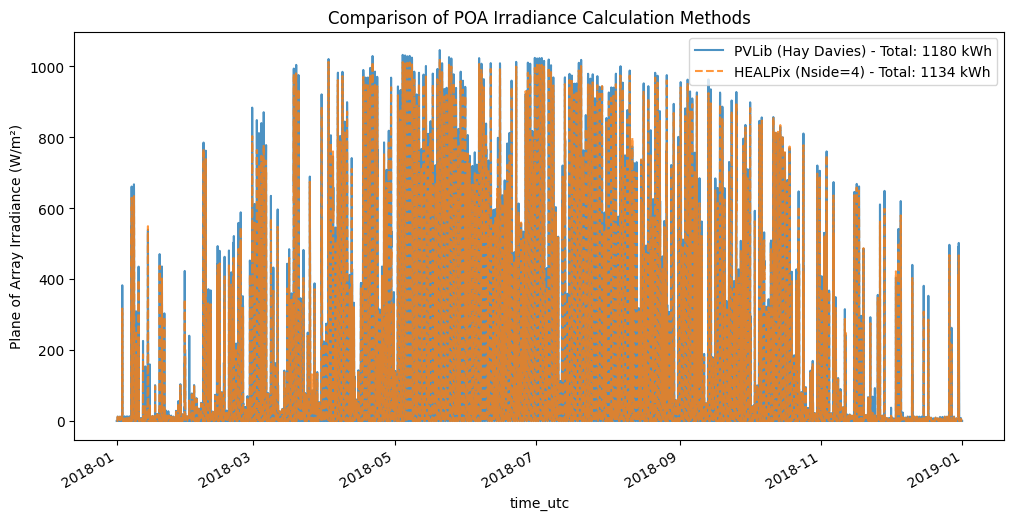

In [27]:
import pandas as pd
import numpy as np
import healpy as hp
import glob
from pvlib.solarposition import get_solarposition
import pvlib # Added for comparison and dni_extra
import pytz # Added for timezone handling
from dataclasses import dataclass, field
from typing import List, Dict, Tuple, Optional
from tqdm import tqdm
import os
from datetime import datetime
import time # For timing comparison

# --- Configuration from Previous Script ---
CSV_FILE_PATH = "big_one_2018/2e8fcc3841698c643301d5e86571d863/682979_54.01_11.58_2018.csv"# Use the specific file from the first example
LATITUDE = 47.25
LONGITUDE = 11.38
ALTITUDE = 666
LOCAL_TIMEZONE_STR = 'Etc/GMT-1' # UTC+1

SURFACE_TILT = 30  # degrees
SURFACE_AZIMUTH = 180 # degrees (South facing)
ALBEDO = 0.2 # Typical ground reflectance
NSIDE = 4 # HEALPix resolution (Keep it relatively low for speed)

# --- 1. Data Loading (Simplified for single file) ---

def load_prepare_single_csv(file_path: str, local_tz_str: str) -> Optional[pd.DataFrame]:
    """Loads and prepares data from a single CSV file."""
    try:
        # Read metadata first (optional, but good practice)
        meta = pd.read_csv(file_path, nrows=1).iloc[0]
        print("--- Metadata Summary ---")
        print(f"Location ID: {meta['Location ID']}")
        print(f"Coordinates: Lat={meta['Latitude']}, Lon={meta['Longitude']}")
        print(f"Elevation: {meta['Elevation']}m")
        print("-" * 22)

        # Read the actual data
        df = pd.read_csv(file_path, skiprows=2)

        # Robust datetime creation and timezone handling
        df['time_local'] = pd.to_datetime(df[['Year', 'Month', 'Day', 'Hour', 'Minute']])
        local_tz = pytz.timezone(local_tz_str)
        df['time_local'] = df['time_local'].dt.tz_localize(local_tz, ambiguous='infer', nonexistent='shift_forward')
        df['time_utc'] = df['time_local'].dt.tz_convert('UTC')
        df = df.set_index('time_utc')

        # Rename columns
        df.rename(columns={
            'DHI': 'dhi', 'GHI': 'ghi', 'DNI': 'dni',
            'Solar Zenith Angle': 'zenith_provided' # Keep for reference if needed
        }, inplace=True)

        # Ensure numeric types and fill NaNs (important!)
        numeric_cols = ['dhi', 'ghi', 'dni']
        for col in numeric_cols:
            df[col] = pd.to_numeric(df[col], errors='coerce')
        df[numeric_cols] = df[numeric_cols].fillna(0)

        print(f"Loaded {len(df)} hourly data points.")
        print(f"Time range: {df.index.min()} to {df.index.max()}")
        return df

    except FileNotFoundError:
        print(f"Error: CSV file not found at {file_path}")
        return None
    except Exception as e:
        print(f"An error occurred during data loading: {e}")
        return None

# --- 2. HEALPix Utilities ---

def get_healpix_info(nside: int) -> Dict:
    """Get basic HEALPix grid information."""
    npix = hp.nside2npix(nside)
    pixel_solid_angle = hp.nside2pixarea(nside) # Steradians (sr)
    pixels = np.arange(npix)
    # Get angles in math convention (theta=colatitude, phi=azimuth E=0)
    theta_rad, phi_rad = hp.pix2ang(nside, pixels, nest=False) # RING scheme
    elevation_rad = np.pi/2 - theta_rad # Elevation (rad)
    azimuth_rad_math = phi_rad # Azimuth (rad, math convention E=0)

    # Also provide navigation azimuth (N=0, E=90) for convenience
    azimuth_deg_nav = np.degrees((np.pi/2 - azimuth_rad_math) % (2*np.pi))

    # Calculate direction vectors (unit vectors pointing from origin to pixel center)
    # x = sin(theta)cos(phi), y = sin(theta)sin(phi), z = cos(theta) [standard physics spherical]
    # Or using elevation/azimuth_math: x=cos(el)cos(az_m), y=cos(el)sin(az_m), z=sin(el)
    # Let's use a common convention like X=East, Y=North, Z=Up
    # East = cos(el)sin(az_nav) -> cos(el)sin(90-az_m) -> cos(el)cos(az_m)
    # North = cos(el)cos(az_nav) -> cos(el)cos(90-az_m) -> cos(el)sin(az_m)
    # Up = sin(el)
    vec_x = np.cos(elevation_rad) * np.cos(azimuth_rad_math)
    vec_y = np.cos(elevation_rad) * np.sin(azimuth_rad_math)
    vec_z = np.sin(elevation_rad)
    direction_vectors = np.vstack((vec_x, vec_y, vec_z)).T # Shape (npix, 3)


    return {
        "nside": nside,
        "npix": npix,
        "pixel_solid_angle": pixel_solid_angle,
        "pixels": pixels,
        "theta_rad": theta_rad, # Co-latitude / Zenith (rad)
        "phi_rad": phi_rad,     # Azimuth Math (E=0) (rad)
        "elevation_rad": elevation_rad,
        "azimuth_rad_math": azimuth_rad_math,
        "azimuth_deg_nav": azimuth_deg_nav, # Azimuth Nav (N=0, E=90) (deg)
        "direction_vectors": direction_vectors # Unit vectors to pixel centers
    }

def azimuth_elevation_to_healpix_pixel(azimuth_rad_math: float, elevation_rad: float, nside: int) -> Optional[int]:
    """
    Convert azimuth (math, E=0) and elevation (radians) to the nearest HEALPix pixel index.
    Handles potential numerical inaccuracies by clipping theta. Returns None if inputs are invalid.
    """
    if not np.isfinite(azimuth_rad_math) or not np.isfinite(elevation_rad):
        return None
    if elevation_rad < -np.pi/2 or elevation_rad > np.pi/2: # Check elevation bounds
         return None

    theta = np.pi/2 - elevation_rad # Co-latitude
    phi = azimuth_rad_math % (2 * np.pi) # Ensure phi in [0, 2pi)

    # Clip theta slightly inside [0, pi] for numerical stability near poles
    theta = np.clip(theta, 1e-9, np.pi - 1e-9)

    try:
        # Use nest=False for RING scheme consistently
        pixel = hp.ang2pix(nside, theta, phi, nest=False)
        return int(pixel)
    except Exception as e:
        print(f"Error in hp.ang2pix: {e}. Inputs: nside={nside}, theta={theta:.4f}, phi={phi:.4f}")
        return None

# --- 3. Sky Radiance Calculation (Revised) ---

def calculate_isotropic_diffuse_radiance(dhi: float, nside: int, hp_info: Dict) -> Tuple[np.ndarray, np.ndarray]:
    """
    Distributes DHI isotropically over the sky hemisphere.
    Isotropic radiance L = DHI / pi.

    Returns:
        Tuple[np.ndarray, np.ndarray]:
            - Indices of visible pixels (elevation > 0).
            - Isotropic diffuse radiance values for visible pixels (W/m²/sr).
    """
    if dhi <= 0:
        return np.array([], dtype=int), np.array([], dtype=float)

    elevation_rad = hp_info['elevation_rad']
    pixels = hp_info['pixels']

    # Select only pixels strictly above the horizon
    visible_mask = elevation_rad > 1e-6 # Use small threshold
    visible_pixels = pixels[visible_mask]

    if len(visible_pixels) == 0:
        return np.array([], dtype=int), np.array([], dtype=float)

    # For isotropic model, radiance is constant across the sky dome
    isotropic_radiance = dhi / np.pi # W/m²/sr

    diffuse_radiance_values = np.full(len(visible_pixels), isotropic_radiance)

    return visible_pixels, diffuse_radiance_values

def calculate_timestep_radiance_map(row: pd.Series, nside: int, hp_info: Dict) -> np.ndarray:
    """
    Calculates the sky radiance map (W/m²/sr) for a single timestep using
    isotropic diffuse and adding direct beam. Requires solar position
    ('zenith', 'azimuth' in degrees) in the row.

    Returns:
        np.ndarray: Sky radiance map for the timestep (W/m²/sr).
    """
    npix = hp_info['npix']
    pixel_solid_angle = hp_info['pixel_solid_angle']
    radiance_map = np.zeros(npix)

    # Check necessary inputs
    if pd.isna(row['dhi']) or pd.isna(row['dni']) or pd.isna(row['zenith']) or pd.isna(row['azimuth']):
        return radiance_map # Return zero map if data missing

    # 1. Diffuse Component (Isotropic)
    dhi = max(0, row['dhi']) # Ensure non-negative
    if dhi > 0:
        visible_pixels, diffuse_radiance = calculate_isotropic_diffuse_radiance(dhi, nside, hp_info)
        if len(visible_pixels) > 0:
            radiance_map[visible_pixels] += diffuse_radiance

    # 2. Direct Component
    dni = max(0, row['dni']) # Ensure non-negative
    solar_zenith_deg = row['zenith']

    # Add DNI only if sun is above the horizon
    if dni > 0 and solar_zenith_deg < 90:
        solar_elevation_rad = np.radians(90.0 - solar_zenith_deg)
        solar_azimuth_deg = row['azimuth'] # pvlib azimuth: N=0, E=90

        # Convert solar azimuth (N=0, E=90) to math convention (E=0, N=90)
        solar_azimuth_rad_math = np.radians((90.0 - solar_azimuth_deg) % 360.0)

        # Get sun pixel index
        sun_pixel = azimuth_elevation_to_healpix_pixel(solar_azimuth_rad_math, solar_elevation_rad, nside)

        if sun_pixel is not None:
            # Add DNI radiance to the sun pixel
            if pixel_solid_angle > 1e-12: # Avoid division by zero
                dni_radiance = dni / pixel_solid_angle # W/m²/sr
                radiance_map[sun_pixel] += dni_radiance
            else:
                 print(f"Warning: Pixel solid angle zero/small for nside={nside}")
    return radiance_map

# --- 4. Tilted Surface Calculation using HEALPix Map ---

def precompute_surface_geometry(surface_tilt_deg: float, surface_azimuth_deg: float, hp_info: Dict) -> Dict:
    """Precomputes geometry needed for POA calculation from HEALPix maps."""
    nside = hp_info['nside']
    npix = hp_info['npix']
    pixel_vectors = hp_info['direction_vectors'] # Shape (npix, 3) [East, North, Up] convention
    pixel_solid_angle = hp_info['pixel_solid_angle']
    elevation_rad = hp_info['elevation_rad']

    # Calculate surface normal vector in East, North, Up coordinates
    tilt_rad = np.radians(surface_tilt_deg)
    azimuth_rad_nav = np.radians(surface_azimuth_deg) # N=0, E=90

    # Normal vector components (pointing away from the collecting surface)
    # See e.g., https://pvpmc.sandia.gov/modeling-steps/1-weather-data/plane-of-array-poa-irradiance/poa-ground-reflected/
    # Or derive using rotations. A common formula:
    nx = np.sin(tilt_rad) * np.sin(azimuth_rad_nav) # East component
    ny = np.sin(tilt_rad) * np.cos(azimuth_rad_nav) # North component
    nz = np.cos(tilt_rad)                         # Up component
    surface_normal = np.array([nx, ny, nz])
    surface_normal /= np.linalg.norm(surface_normal) # Ensure unit vector

    # Calculate cosine of Angle of Incidence (AOI) for each HEALPix pixel
    # cos(AOI) = surface_normal ⋅ pixel_vector
    # Clip results between 0 and 1 (cos(AOI) cannot be > 1, ignore angles > 90 deg)
    cos_aoi = np.dot(pixel_vectors, surface_normal)
    cos_aoi = np.clip(cos_aoi, 0, 1) # Interested only in pixels hitting the front face (cos_aoi > 0)

    # Identify pixels visible to the surface (cos_aoi > 0) and above horizon (elevation > 0)
    sky_mask = (elevation_rad > 1e-6) & (cos_aoi > 1e-9)
    visible_sky_pixels = hp_info['pixels'][sky_mask]

    # Precompute integration weights for visible sky pixels
    sky_integration_weights = cos_aoi[sky_mask] * pixel_solid_angle

    return {
        "surface_normal": surface_normal,
        "cos_aoi": cos_aoi, # For all pixels
        "visible_sky_pixels": visible_sky_pixels,
        "sky_integration_weights": sky_integration_weights,
        "tilt_rad": tilt_rad
    }


def calculate_poa_from_healpix(row: pd.Series, nside: int, hp_info: Dict, surface_geom: Dict, albedo: float) -> float:
    """
    Calculates the POA irradiance (W/m²) for a single timestep using the HEALPix radiance map.
    """
    # Check if essential data is present and valid
    if pd.isna(row['ghi']) or pd.isna(row['dhi']) or pd.isna(row['dni']) or pd.isna(row['zenith']) or pd.isna(row['azimuth']):
         return 0.0 # Cannot calculate if data missing
    if row['ghi'] < 0: # Skip if GHI is negative
         return 0.0

    # 1. Calculate Sky Radiance Map for this timestep
    sky_radiance_map = calculate_timestep_radiance_map(row, nside, hp_info)

    # 2. Integrate Sky Radiance over the Tilted Surface
    visible_sky_pixels = surface_geom['visible_sky_pixels']
    sky_integration_weights = surface_geom['sky_integration_weights']

    # Sum(L_sky * cos(AOI) * pixel_solid_angle) over visible sky pixels
    poa_sky = np.sum(sky_radiance_map[visible_sky_pixels] * sky_integration_weights)

    # 3. Calculate Ground Reflected Component (using standard isotropic formula)
    ghi = max(0, row['ghi']) # Ensure non-negative
    tilt_rad = surface_geom['tilt_rad']
    poa_ground = ghi * albedo * (1.0 - np.cos(tilt_rad)) / 2.0

    # 4. Total POA Irradiance
    total_poa = poa_sky + poa_ground

    # Ensure non-negative result
    return max(0.0, total_poa)

# --- 5. Main Execution ---

if __name__ == "__main__":
    # --- Load Data ---
    print("Loading and preparing CSV data...")
    df = load_prepare_single_csv(CSV_FILE_PATH, LOCAL_TIMEZONE_STR)

    if df is None:
        print("Exiting due to data loading error.")
        exit()

    # --- Calculate Solar Position and Extraterrestrial Radiation ---
    print("Calculating solar positions...")
    location = pvlib.location.Location(latitude=LATITUDE, longitude=LONGITUDE,
                                       tz='UTC', altitude=ALTITUDE)
    solar_position = location.get_solarposition(df.index, temperature=12) # Use average temp
    # Add calculated solar position to DataFrame
    df = df.join(solar_position[['zenith', 'azimuth']], how='left')

    print("Calculating extraterrestrial radiation...")
    dni_extra = pvlib.irradiance.get_extra_radiation(df.index)
    df['dni_extra'] = dni_extra # Needed for pvlib comparison

    # Drop rows where solar position might be missing (e.g., due to time conversion issues)
    initial_rows = len(df)
    df.dropna(subset=['zenith', 'azimuth', 'dni_extra', 'dhi', 'ghi', 'dni'], inplace=True)
    if len(df) < initial_rows:
        print(f"Warning: Dropped {initial_rows - len(df)} rows with missing data.")

    if df.empty:
         print("Error: No valid data remaining after processing. Exiting.")
         exit()

    # --- Method 1: Standard PVLib Transposition ---
    print("\n--- Calculating POA using pvlib.irradiance.get_total_irradiance ---")
    start_time_pvlib = time.time()
    poa_pvlib = pvlib.irradiance.get_total_irradiance(
        surface_tilt=SURFACE_TILT,
        surface_azimuth=SURFACE_AZIMUTH,
        solar_zenith=df['zenith'],
        solar_azimuth=df['azimuth'],
        dni=df['dni'],
        ghi=df['ghi'],
        dhi=df['dhi'],
        dni_extra=df['dni_extra'],
        albedo=ALBEDO,
        model='haydavies' # Using Hay Davies like the original example
    )
    df['poa_pvlib'] = poa_pvlib['poa_global'].clip(lower=0)
    total_energy_pvlib_wh = df['poa_pvlib'].sum() # Assumes hourly data
    total_energy_pvlib_kwh = total_energy_pvlib_wh / 1000.0
    end_time_pvlib = time.time()
    print(f"PVLib Calculation Time: {end_time_pvlib - start_time_pvlib:.2f} seconds")

    # --- Method 2: HEALPix Timestep Calculation ---
    print(f"\n--- Calculating POA using HEALPix (Nside={NSIDE}) Timestep Integration ---")
    start_time_hp = time.time()
    # Precompute HEALPix grid info and surface geometry
    hp_info = get_healpix_info(NSIDE)
    surface_geom = precompute_surface_geometry(SURFACE_TILT, SURFACE_AZIMUTH, hp_info)

    # Apply the calculation row-wise (can be slow for large datasets)
    # Consider parallelization (e.g., joblib, dask) for large datasets if needed.
    poa_healpix_list = []
    for index, row in tqdm(df.iterrows(), total=len(df), desc="Processing Timesteps"):
        poa_ts = calculate_poa_from_healpix(row, NSIDE, hp_info, surface_geom, ALBEDO)
        poa_healpix_list.append(poa_ts)

    df['poa_healpix'] = poa_healpix_list
    total_energy_healpix_wh = df['poa_healpix'].sum() # Assumes hourly data
    total_energy_healpix_kwh = total_energy_healpix_wh / 1000.0
    end_time_hp = time.time()
    print(f"HEALPix Calculation Time: {end_time_hp - start_time_hp:.2f} seconds")

    # --- Compare Results ---
    print("\n--- Comparison of Yearly Energy (kWh/m²/year) ---")
    print(f"Method                  | Yearly Energy (kWh/m²) | Calculation Time (s)")
    print(f"------------------------|--------------------------|---------------------")
    print(f"PVLib (Hay Davies)      | {total_energy_pvlib_kwh: >24.2f} | {end_time_pvlib - start_time_pvlib: >19.2f}")
    print(f"HEALPix (Nside={NSIDE}, Iso) | {total_energy_healpix_kwh: >24.2f} | {end_time_hp - start_time_hp: >19.2f}")

    diff_kwh = total_energy_healpix_kwh - total_energy_pvlib_kwh
    if abs(total_energy_pvlib_kwh) > 1e-6: # Avoid division by zero
        diff_perc = 100.0 * diff_kwh / total_energy_pvlib_kwh
        print(f"\nDifference (HEALPix - PVLib): {diff_kwh:.2f} kWh/m² ({diff_perc:.2f}%)")
    else:
        print(f"\nDifference (HEALPix - PVLib): {diff_kwh:.2f} kWh/m²")

    # Optional: Plot comparison
    try:
        import matplotlib.pyplot as plt
        plt.figure(figsize=(12, 6))
        df['poa_pvlib'].plot(label=f'PVLib (Hay Davies) - Total: {total_energy_pvlib_kwh:.0f} kWh', alpha=0.8)
        df['poa_healpix'].plot(label=f'HEALPix (Nside={NSIDE}) - Total: {total_energy_healpix_kwh:.0f} kWh', alpha=0.8, linestyle='--')
        plt.ylabel('Plane of Array Irradiance (W/m²)')
        plt.title('Comparison of POA Irradiance Calculation Methods')
        plt.legend()
        plt.show()
    except ImportError:
        print("\nInstall matplotlib to see a plot comparing the time series.")